In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Input
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, Flatten, SimpleRNN, Input


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Thesis/Pos Neg.csv")

In [ ]:
# Data preprocessing
X = df.drop(columns=['class'])
Y = df['class']


In [ ]:
# Convert non-numeric values to NaN and drop them
X = X.apply(pd.to_numeric, errors='coerce').dropna()
Y = Y.loc[X.index]

In [ ]:
# Normalize the feature data
scaler = MinMaxScaler().fit(X)
X = scaler.transform(X)
X = np.nan_to_num(X.astype('float32'))

In [ ]:
# Reduce dataset size for visualization
subset_fraction = 0.2  # Take only 20% of the dataset for visualization
subset_indices = np.random.choice(len(X), int(len(X) * subset_fraction), replace=False)
X_subset, Y_subset = X[subset_indices], Y.iloc[subset_indices]

In [ ]:
# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_subset)

In [ ]:
# Split dataset for training/testing
X_train, X_test, Y_train, Y_test = train_test_split(X_tsne, Y_subset, test_size=0.2, random_state=42, stratify=Y_subset)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings

[LightGBM] [Info] Number of positive: 644, number of negative: 1172
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 1816, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.354626 -> initscore=-0.598768
[LightGBM] [Info] Start training from score -0.598768


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:49:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


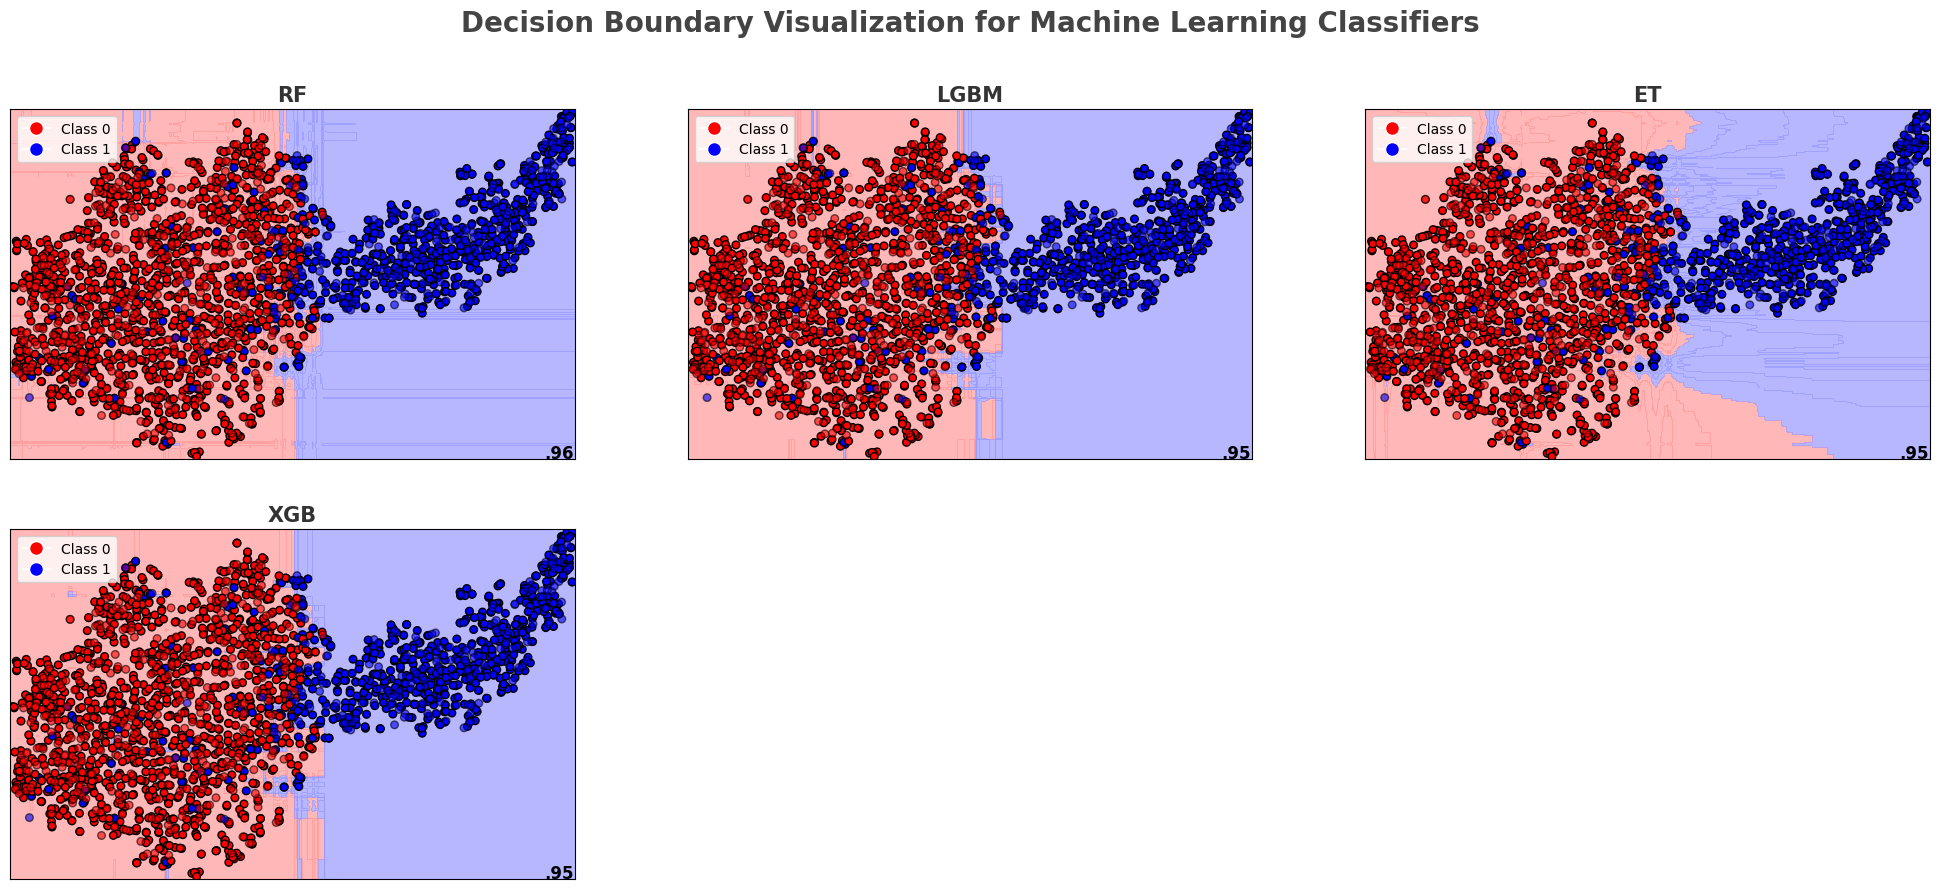

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
7515/7515 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
7515/7515 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7515/7515 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7515/7515 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7515/7515 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


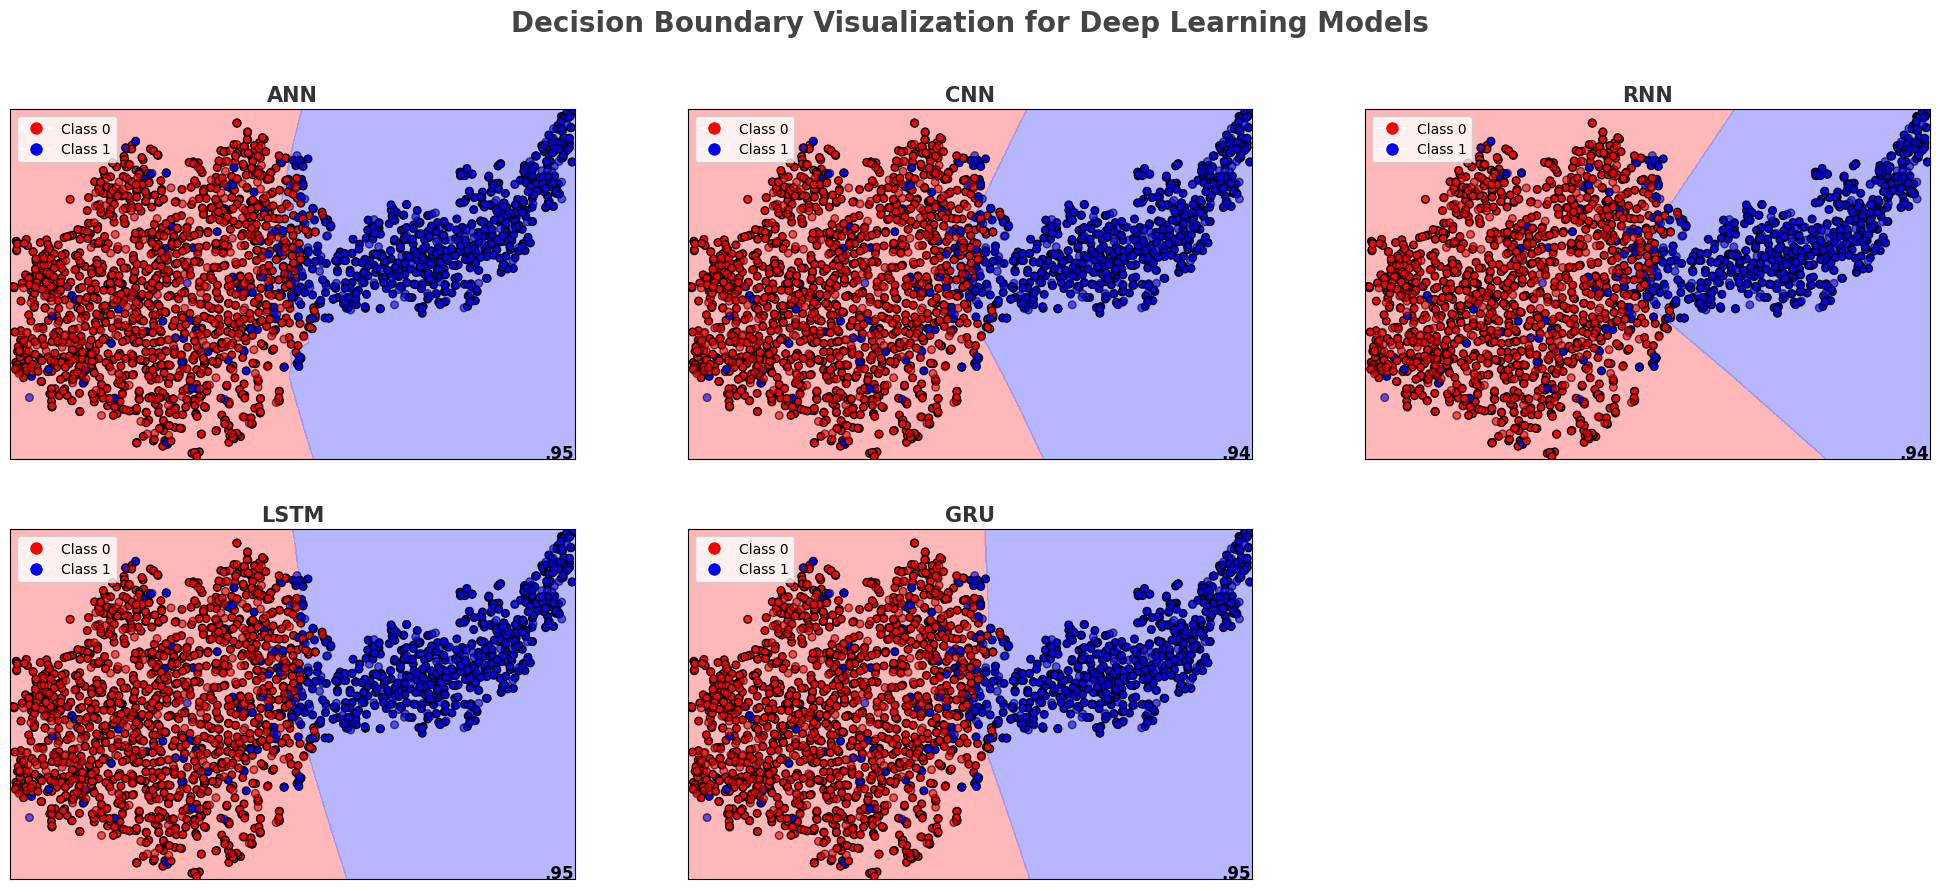

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv1D, Flatten, SimpleRNN, LSTM, GRU
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import lightgbm as lgb
import xgboost as xgb

# Define classifiers
ml_classifiers = {
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "LGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42),
    "ET": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGB": xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric="logloss"),
}

# ANN Model
ann = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
ann.fit(X_train, Y_train, epochs=10, verbose=0)

# CNN Model
cnn = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(32, kernel_size=2, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# RNN Model
rnn = Sequential([
    SimpleRNN(32, activation="relu", input_shape=(X_train.shape[1], 1)),
    Dense(1, activation="sigmoid")
])
rnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# LSTM Model
lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(32, return_sequences=False),
    Dense(1, activation="sigmoid")
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# GRU Model
gru = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    GRU(32, return_sequences=False),
    Dense(1, activation="sigmoid")
])
gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
gru.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# Deep learning models dictionary
dl_classifiers = {"ANN": ann, "CNN": cnn, "RNN": rnn, "LSTM": lstm, "GRU": gru}

# Create meshgrid for decision boundaries
h = 0.2
x_min, x_max = X_tsne[:, 0].min() - 0.5, X_tsne[:, 0].max() + 0.5
y_min, y_max = X_tsne[:, 1].min() - 0.5, X_tsne[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Define colors
decision_boundary_cmap = ListedColormap(["#FF9999", "#9999FF"])  # Light Red & Light Blue
class_0_color = "#FF0000"  # Red for Class 0 dots
class_1_color = "#0000FF"  # Blue for Class 1 dots

# Function to plot classifiers
def plot_classifiers(classifiers, title):
    figure = plt.figure(figsize=(20, 10))
    i = 1

    for name, clf in classifiers.items():
        ax = plt.subplot(2, 3, i)

        # Train classifier & calculate accuracy
        if name in dl_classifiers:
            X_test_reshaped = X_test.reshape(-1, X_train.shape[1], 1)
            Y_pred = (clf.predict(X_test_reshaped) > 0.5).astype(int).flatten()
            score = np.mean(Y_pred == Y_test)
            Z = (clf.predict(np.c_[xx.ravel(), yy.ravel()].reshape(-1, X_train.shape[1], 1)) > 0.5).astype(int).flatten()
        else:
            clf.fit(X_train, Y_train)
            score = clf.score(X_test, Y_test)
            if hasattr(clf, "decision_function"):
                Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
            else:
                Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

        # Reshape and plot decision boundary
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=decision_boundary_cmap, alpha=0.7)

        # Add legend for decision boundary classes
        handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_0_color, markersize=10, label="Class 0"),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_1_color, markersize=10, label="Class 1")
        ]
        ax.legend(handles=handles, loc="upper left", fontsize=10)

        # Scatter plot for train/test points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap=ListedColormap([class_0_color, class_1_color]), edgecolors="black", s=30, label="Train Data")
        ax.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=ListedColormap([class_0_color, class_1_color]), alpha=0.6, edgecolors="black", s=30, label="Test Data")

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        ax.set_title(name, fontsize=15, fontweight="bold", color="#333333")

        # Display accuracy score
        ax.text(xx.max() - 0.3, yy.min() + 0.2, f"{score:.2f}".lstrip("0"), size=12, horizontalalignment="right", color="black", fontweight="bold")

        i += 1

    figure.subplots_adjust(left=0.02, right=0.98)
    plt.suptitle(title, fontsize=20, fontweight="bold", color="#444444")
    plt.show()

# Plot machine learning models
plot_classifiers(ml_classifiers, "Decision Boundary Visualization for Machine Learning Classifiers")

# Plot deep learning models
plot_classifiers(dl_classifiers, "Decision Boundary Visualization for Deep Learning Models")
